#Анализ рынка автомобилей
###Цель: выявить ключевые факторы, влияющие на цену подержанного автомобиля.

###Загрузка необходимых библиотек и датасета данных

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

file_path = '/content/sample_data/car data.csv'
df = pd.read_csv(file_path)

print("Данные загружены. Размер:", df.shape)
print(df.head())

Данные загружены. Размер: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


###Очистка данных

In [15]:
print("\nПропущенные значения:")
print(df.isnull().sum())

df = df.drop_duplicates()


Пропущенные значения:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


###Визуализация распределения цен и зависимости от года выпуска

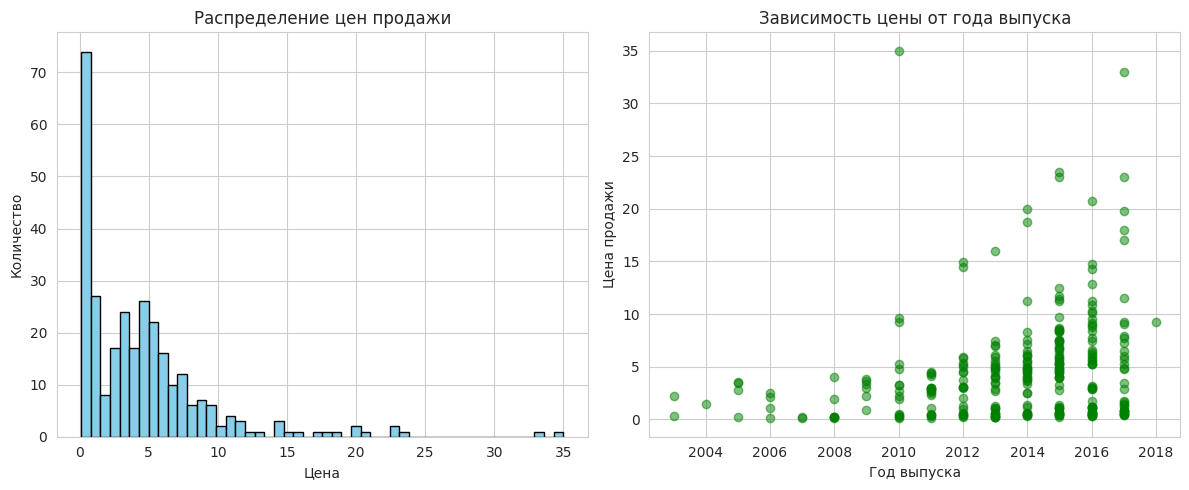

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['Selling_Price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цен продажи')
plt.xlabel('Цена')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
plt.scatter(df['Year'], df['Selling_Price'], alpha=0.5, color='green')
plt.title('Зависимость цены от года выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Цена продажи')
plt.tight_layout()
plt.show()


###Корреляционный анализ

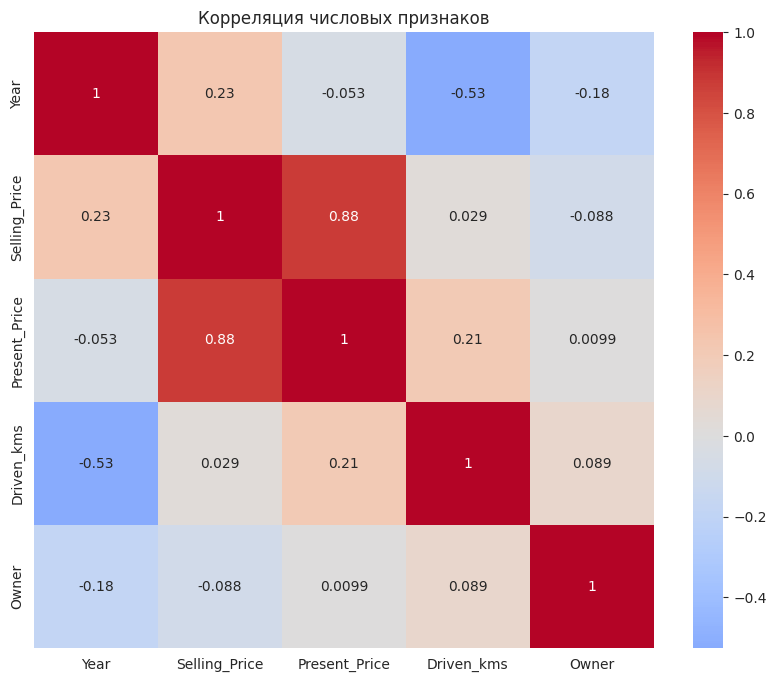

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

###Анализ по категориям

In [18]:
print("\nТоп-5 самых дорогих автомобилей:")
print(df.nlargest(5, 'Selling_Price')[['Car_Name', 'Selling_Price', 'Year']])

print("\nСредняя цена по типу топлива:")
print(df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False))

print("\nСредняя цена по типу продавца:")
print(df.groupby('Selling_type')['Selling_Price'].mean())

print("\nСредняя цена по типу трансмиссии:")
print(df.groupby('Transmission')['Selling_Price'].mean())


Топ-5 самых дорогих автомобилей:
        Car_Name  Selling_Price  Year
86  land cruiser           35.0  2010
64      fortuner           33.0  2017
63      fortuner           23.5  2015
51      fortuner           23.0  2015
82        innova           23.0  2017

Средняя цена по типу топлива:
Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64

Средняя цена по типу продавца:
Selling_type
Dealer        6.632021
Individual    0.870943
Name: Selling_Price, dtype: float64

Средняя цена по типу трансмиссии:
Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


###Ключевые выводы

In [20]:
print(f"Диапазон цен: от {df['Selling_Price'].min()} до {df['Selling_Price'].max()}")
print(f"Средняя цена: {df['Selling_Price'].mean():.2f}")
print(f"Медианная цена: {df['Selling_Price'].median():.2f}")
diff_diesel_petrol = df[df['Fuel_Type']=='Diesel']['Selling_Price'].mean() - df[df['Fuel_Type']=='Petrol']['Selling_Price'].mean()
print(f"Дизельные авто стоят в среднем на {diff_diesel_petrol:.2f} дороже бензиновых")
diff_auto_manual = df[df['Transmission']=='Automatic']['Selling_Price'].mean() - df[df['Transmission']=='Manual']['Selling_Price'].mean()
print(f"Автомат дороже механики на {diff_auto_manual:.2f}")

Диапазон цен: от 0.1 до 35.0
Средняя цена: 4.59
Медианная цена: 3.51
Дизельные авто стоят в среднем на 6.84 дороже бензиновых
Автомат дороже механики на 5.15
